In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
np.set_printoptions(legacy='1.25')

h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

In [2]:
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [3]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1)
b_index = 0
bmax = max(btunes)
    
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0
print(m2_1s)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=m2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))

print(ket2basis.kets)

[-0.5  0.5]
[KetAtom(Cs:57,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2)]


In [4]:
# setting target and resonant states
ket0_tuples = []
ket1_tuples = []
for ket1 in ket1basis.kets:
    for ket2 in ket2basis.kets:
         ket0_tuples.append((ket1, ket2))
for ket1_1 in ket1_1basis.kets:
    for ket2_1 in ket2_1basis.kets: 
        ket1_tuples.append((ket1_1, ket2_1))
print(len(ket0_tuples))

tuple0 = ket0_tuples[0]
tuple1 = ket1_tuples[1]

deltaM = tuple1[0].m + tuple1[1].m - tuple0[0].m - tuple0[1].m

ket_tuples = (tuple0, tuple1)

print(deltaM, ket_tuples)


4
1.0 ((KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2)))


In [25]:
eff_system = pi.EffectiveSystemPair(ket_tuples)
print(ket_tuples)


rs = [5, 10, 15, 20, 25, 5000]
rs=rs[1:2]
thetas = [0, 45, 90]
thetas=thetas[:1]
bs = np.linspace(0, bmax+2, 500)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\magnetic\\2x2 hams avg\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

for theta in thetas:
    for r in rs:  

        eff_h_dict_elements = {'bs' : [], '00' : [], '01' : [], '10' : [], '11' : []}
        if not os.path.exists(datapath + f'{n1_0}{n2_0} m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}) theta {theta}, sep {r}um1.csv'):
            
            eff_system = eff_system.set_distance(r, angle_degree=theta, unit="micrometer")
            eff_system.set_diamagnetism_enabled(True)
            eff_system.set_minimum_number_of_ket_pairs(1_000)
            

            eff_h_dict_elements["bs"] = bs

            for mag in bs:
                pair_energy_pm = eff_system.get_pair_energies("MHz")[0]
                eff_system = eff_system.set_magnetic_field([0,0,mag], unit="G")
                H = eff_system.get_effective_hamiltonian(unit="MHz") - np.diag(eff_system.get_pair_energies("MHz"))

                eff_h_dict_elements["00"].append(H[0,0])
                eff_h_dict_elements["01"].append(H[0,1])
                eff_h_dict_elements["10"].append(H[1,0])
                eff_h_dict_elements["11"].append(H[1,1])

            pd.DataFrame(eff_h_dict_elements).to_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}) theta {theta}, sep {r}um.csv', index = False)

((KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2)))


The ket |~Rb:59,S_1/2,-1/2; ~Cs:57,S_1/2,-1/2⟩ has only 0.894 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ with overlap 4.486e-01
The ket |~Rb:59,S_1/2,-1/2; ~Cs:57,S_1/2,-1/2⟩ has only 0.885 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |~Rb:58,P_1/2,-1/2; ~Cs:57,P_1/2,-1/2⟩ with overlap 4.649e-01
The ket |~Rb:59,S_1/2,-1/2; ~Cs:57,S_1/2,-1/2⟩ has only 0.876 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |~Rb:58,P_1/2,-1/2; ~Cs:57,

In [26]:
H = {f'{r}{theta}' : pd.read_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}) theta {theta}, sep {r}um.csv') for r in rs for theta in thetas}
print(H)
matrix_lists = {f'{r}{theta}' : [[[H[f'{r}{theta}']['00'][i], H[f'{r}{theta}']['01'][i]], [H[f'{r}{theta}']['10'][i], H[f'{r}{theta}']['11'][i]]] for i in range(len(H[f'{r}{theta}']))] for r in rs for theta in thetas}

matrix_lists = {f'{r}{theta}' : [[[H[f'{r}{theta}']['00'][i], H[f'{r}{theta}']['01'][i]], [H[f'{r}{theta}']['10'][i], H[f'{r}{theta}']['11'][i]]] for i in range(len(H[f'{r}{theta}']))] for r in rs for theta in thetas}

eval_list = {f'{r}{theta}' : [np.linalg.eigh(matrix)[0] for matrix in matrix_lists[f'{r}{theta}']] for r in rs for theta in thetas}
evec_list = {f'{r}{theta}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{r}{theta}']] for r in rs for theta in thetas}
bs = {f'{r}{theta}' : H[f'{r}{theta}']['bs'] for r in rs for theta in thetas}

{'100':             bs        00   01   10        11
0     0.000000  0.266190  0.0  0.0 -0.671288
1     0.040615  0.267803  0.0  0.0 -0.671304
2     0.081230  0.269431  0.0  0.0 -0.671321
3     0.121844  0.271074  0.0  0.0 -0.671337
4     0.162459  0.272732  0.0  0.0 -0.671353
..         ...       ...  ...  ...       ...
495  20.104321 -0.369061  0.0  0.0 -0.659757
496  20.144936 -0.368034  0.0  0.0 -0.659694
497  20.185551 -0.367015  0.0  0.0 -0.659631
498  20.226165 -0.366003  0.0  0.0 -0.659568
499  20.266780 -0.364998  0.0  0.0 -0.659505

[500 rows x 5 columns]}


0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2))


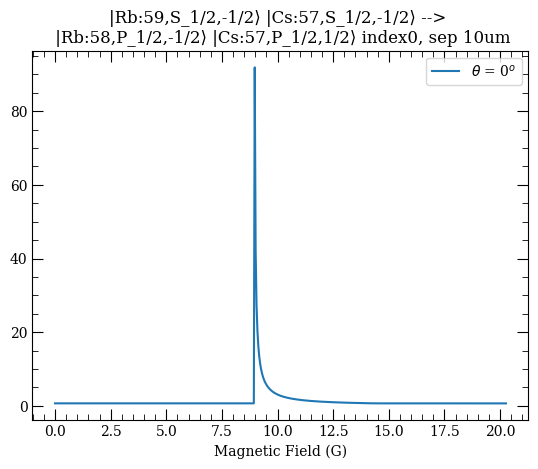

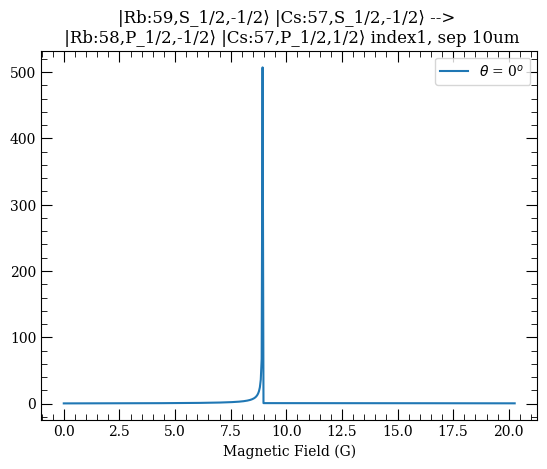

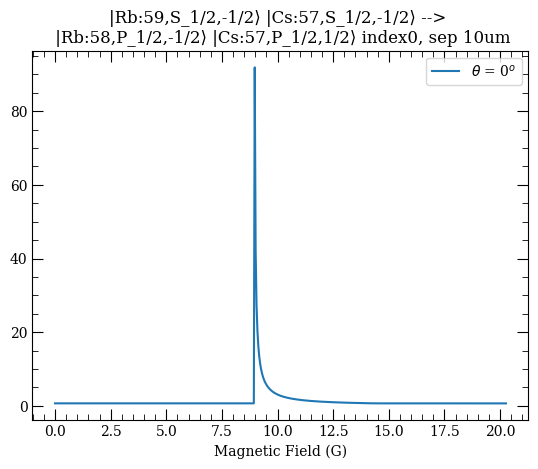

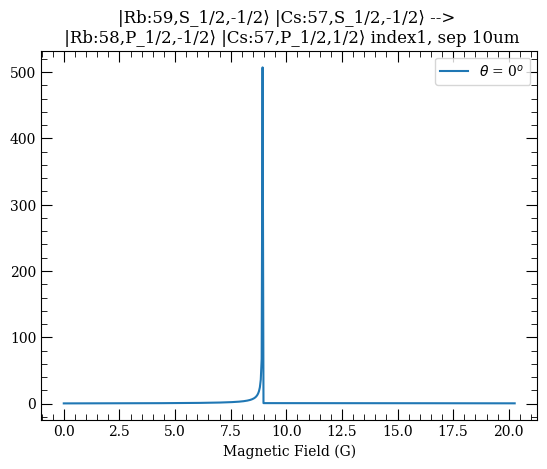

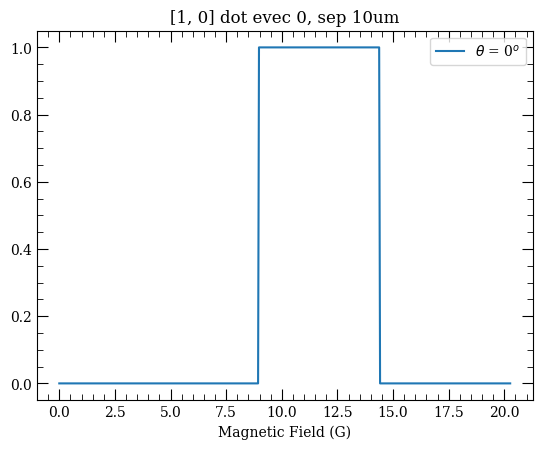

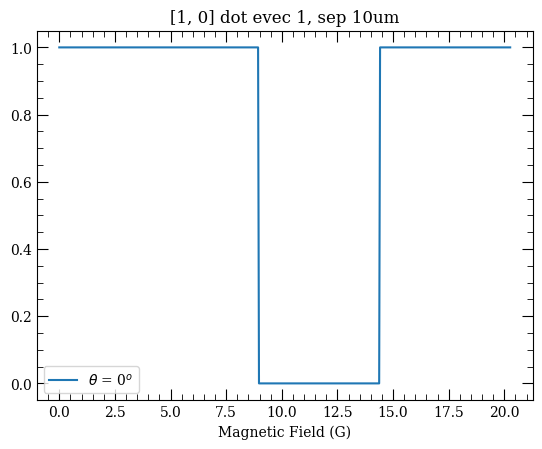

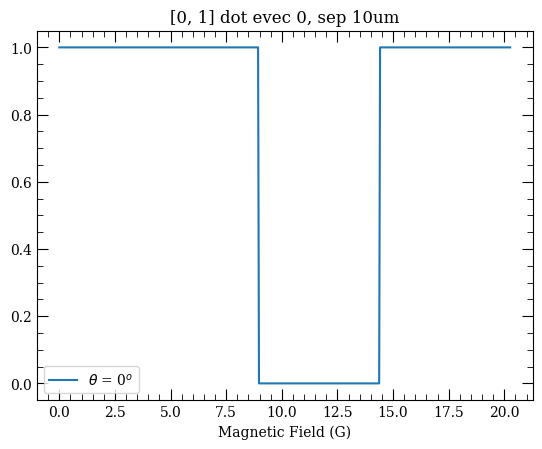

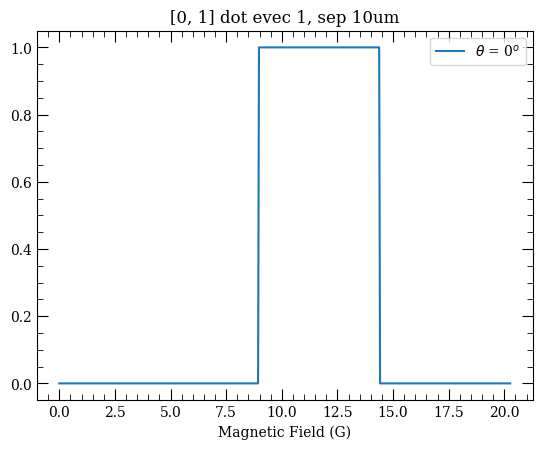

In [27]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\magnetic\\2x2 hams avg\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

tups = [[1,0], [0,1]]

overlap = {f'{r}{theta}' : {f'{index}{tup}' : [abs(np.dot(tup, evec[index])) for evec in evec_list[f'{r}{theta}']] for index in range(2) for tup in tups} for r in rs for theta in thetas}
Ediag = {f'{r}{theta}' : {f'{index}' : [eval[index] for eval in eval_list[f'{r}{theta}']] for index in range(2)} for r in rs for theta in thetas}

r = 10

for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        for theta in thetas:         
            ax.plot(bs[f'{r}{theta}'], abs(np.array(Ediag[f'{r}{theta}'][f'{index}'])), "-", label = fr'$\theta$ = {theta}$^o$')

        ax.legend()
        ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index}, sep {r}um')
        ax.set_xlabel(r"Magnetic Field (G)")
        plt.savefig(figpath + f'overlaps\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

    plt.show()


for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        for theta in thetas:         
            ax.plot(bs[f'{r}{theta}'], overlap[f'{r}{theta}'][f'{index}{tup}'], label = fr'$\theta$ = {theta}$^o$') 
        ax.legend()
        ax.set_xlabel(r"Magnetic Field (G)")
        ax.set_title(f'{tup} dot evec {index}, sep {r}um')
        
        plt.savefig(figpath + f'\\eigenenergies\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

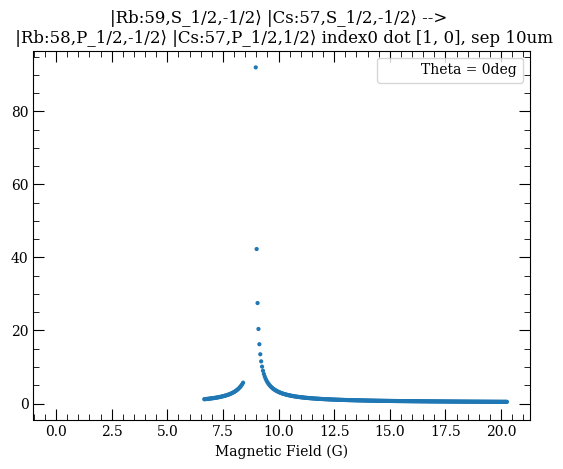

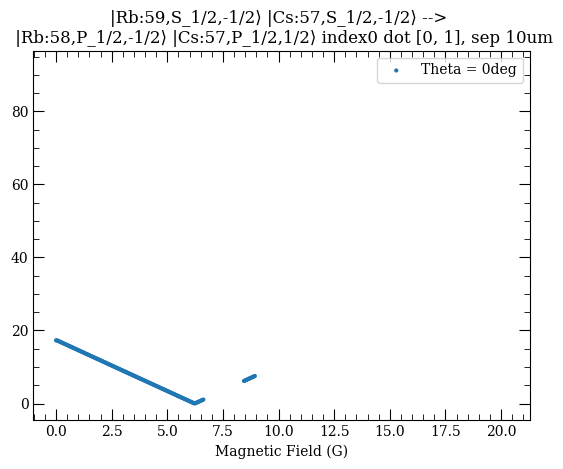

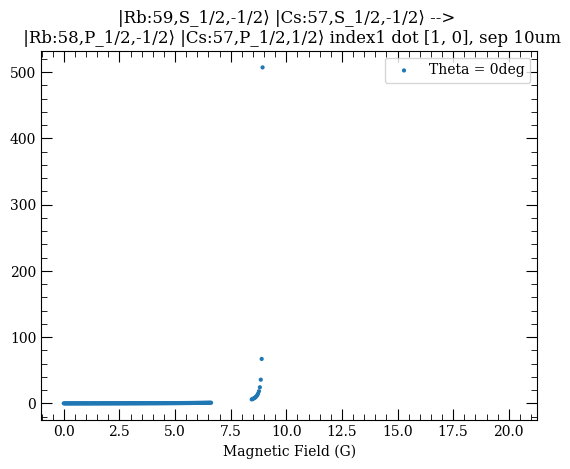

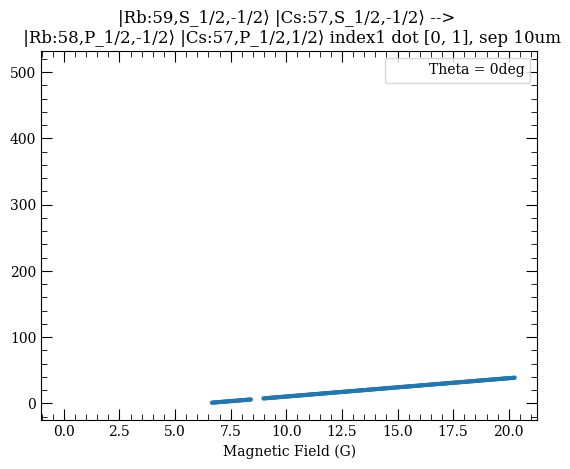

In [23]:
for r in rs:
    for index in range(2):
        for tup in tups:

            fig, ax = plt.subplots()
            for theta in thetas:         
                
                ax.scatter(bs[f'{r}{theta}'],
                            abs(np.array(Ediag[f'{r}{theta}'][f'{index}'])),
                            alpha=overlap[f'{r}{theta}'][f'{index}{tup}'],
                            marker='.',
                            linewidths=.01,
                            label = fr'Theta = {theta}deg')
            ax.legend()
            ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index} dot {tup}, sep {r}um')
            ax.set_xlabel(r"Magnetic Field (G)")
            plt.savefig(figpath + f'overlaps\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

        plt.show()

In [ ]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\magnetic\\2x2 hams avg\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

r = 10
theta = 0

for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        for r in rs:         
            ax.plot(bs[f'{r}{theta}'], abs(np.array(Ediag[f'{r}{theta}'][f'{index}{tup}'])), "-", label = fr'r = {r}um')

        ax.legend()
        ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index}, $\theta$ = {theta}$^o$')
        ax.set_xlabel(r"Magnetic Field (G)")
        plt.savefig(figpath + f'overlaps\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), theta {theta}deg, e {np.round(e,1)}Vcm evec {index}.png')

    plt.show()


for tup in tups:
    for index in range(2):
        fig, ax = plt.subplots()
        for r in rs:
            ax.plot(bs[f'{r}{theta}'], overlap[f'{r}{theta}'][f'{index}{tup}'], label = fr'r = {r}um') 
        ax.legend()
        ax.set_xlabel(r"Magnetic Field (G)")
        ax.set_title(fr'{tup} dot evec {index}, $\theta$ = {theta}$^o$')
        
        plt.savefig(figpath + f'\\eigenenergies\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), theta {theta}deg, e {np.round(e,1)}Vcm evec {index}.png')